# Opis

Notatnik służący do wizualizacji przestrzeni ukrytej autoenkoderów

In [2]:
IS_NEW_APPROACH = True
IS_VGAE = True

# Importy

In [50]:
%load_ext autoreload
%autoreload 2
import json
import matplotlib.pyplot as plt

import sys

sys.path.append('../')
import torch
from utils.FramsticksGraphDataset import FramsticksGraphDataset
from pyprojroot import here
from src.models.KlejdaGAE.KlejdaGraphAutoencoder import KlejdaGraphAutoencoder
from src.models.KlejdaGAE.KlejdaVariationalGraphAutoencoder import KlejdaVariationalGraphAutoencoder
from src.models.NewGAE.GraphAutoencoder import GraphAutoencoder
from src.models.NewGAE.VariationalGraphAutoencoder import VariationalGraphAutoencoder
import yaml
from torch.utils.data import Dataset, DataLoader, random_split

import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import kaleido
import plotly
import plotly.express as px
import pandas as pd
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

pio.renderers.default = "notebook"  # lub "jupyterlab" zależnie od środowiska
current_dir = os.getcwd()
framspy_path = os.path.abspath(os.path.join(current_dir, '..', 'external', 'framspy'))
if framspy_path not in sys.path:
	sys.path.insert(0, framspy_path)
with open("../configs/final_evolution_config.yaml", 'r') as f:
	evolution_config = yaml.safe_load(f)
from FramsticksLib import FramsticksLib
import frams

frams.init(
	evolution_config['frams_path']
)
frams_lib = FramsticksLib(evolution_config['frams_path'], evolution_config['frams_lib'], evolution_config['sim_file'])

genotypes = []
with open("../results/sampled_best_individuals_new_mini_merged.jsonl", "r", encoding="utf-8") as f:
	for line in f:
		obj = json.loads(line.strip())
		genotypes.append(obj)
from src.deap.AutoencoderEvaluator import AutoencoderEvaluator


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data

Using Framsticks version: 5.5
Home (writable) dir     : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data
Resources dir           : C:\Users\witek\PycharmProjects\Magisterka\external\Framsticks55\data

Available objects: ['CheckpointEvent', 'Collision', 'CrCollision', 'Creature', 'CreatureSettings', 'CreatureSignals', 'CreatureSnapshot', 'Dictionary', 'ExpProperties', 'ExpState', 'ExtValue', 'File', 'FunctionReference', 'GenMan', 'GenManStats', 'GenePool', 'GenePools', 'Geno', 'GenoConverters', 'Genotype', 'Interface', 'Joint', 'Loader', 'Math', 'MechJoint', 'MechPart', 'MessageCatcher', 'Model', 'ModelGeometry', 'ModelSymmetry', 'Neuro', 'NeuroClass', 'NeuroClass

# Przygotowanie autoenkodera

In [4]:
project_dir = here()
# Przygotowanie checkpointów nauczonych autoenkoderów
checkpoints_dir = project_dir / 'notebooks' / 'checkpoints' / 'final_checkpoints'

if IS_NEW_APPROACH:
	checkpoints_dir = checkpoints_dir / 'new'
else:
	checkpoints_dir = checkpoints_dir / 'klejda'
checkpoint_gae = torch.load(checkpoints_dir / 'gae.ckpt')
checkpoint_vgae = torch.load(checkpoints_dir / 'vgae.ckpt')
# Przygotowanie konfiguracji dla gae
configs_dir = project_dir / 'configs'

if IS_NEW_APPROACH:
	config_gae_path = configs_dir / 'gae_config_large.yaml'
	config_vgae_path = configs_dir / 'gae_config_large.yaml'
else:
	config_gae_path = configs_dir / 'klejda_gae_config.yaml'
	config_vgae_path = configs_dir / 'klejda_gae_config.yaml'

with open(config_gae_path) as f:
	config_gae = yaml.safe_load(f)
with open(config_vgae_path) as f:
	config_vgae = yaml.safe_load(f)
torch.set_printoptions(precision=10)

## Przygotowanie macierzy wektorów ukrytych

In [5]:
NUMBER_OF_EXAMPLES = 1000

dataset = FramsticksGraphDataset(genotypes, config_gae["max_nodes"])
dataset_size = len(dataset)

dataloader = DataLoader(
	dataset,
	batch_size=1,
	shuffle=True,
	num_workers=2,
	persistent_workers=True
)

if IS_VGAE:
	if IS_NEW_APPROACH:
		autoencoder = VariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	else:
		autoencoder = KlejdaVariationalGraphAutoencoder(config=config_vgae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_vgae['state_dict'])
else:
	if IS_NEW_APPROACH:
		autoencoder = GraphAutoencoder(config=config_gae, frams_module=frams)
	else:
		autoencoder = KlejdaGraphAutoencoder(config=config_gae, frams_module=frams)
	autoencoder.load_state_dict(checkpoint_gae['state_dict'])

device = torch.device("cpu")
autoencoder = autoencoder.to(device)

autoencoder.eval()

latent_vectors = []
labels = []

with torch.no_grad():
	for i, batch in enumerate(dataloader):
		if i >= NUMBER_OF_EXAMPLES:
			break
		# Rozpakowanie batcha
		x_matrix = batch[0]
		a_matrix = batch[1]
		label = batch[2][config_gae['locality_loss_type']].squeeze(0).tolist()
		if config_gae['locality_loss_type'] == 'fitness':
			label = label[0]
		labels.append(label)
		z = autoencoder.encode(x_matrix, a_matrix)
		# Spakowanie do batcha
		z_single = z.squeeze(0)

		latent_vectors.append(z_single)
latent_vectors = np.array(latent_vectors)
print(f"Pomyślnie wygenerowano {len(latent_vectors)} wektorów ukrytych.")
# Przykładowy podgląd kształtu pierwszego wektora
print(f"Kształt pojedynczego wektora z: {latent_vectors[0].shape}")
# print(f"Labels: {labels}")

Pomyślnie wygenerowano 1000 wektorów ukrytych.
Kształt pojedynczego wektora z: (15,)


# Wizualizacja przestrzeni ukrytej

## PCA 2D

Generowanie wizualizacji PCA dla fitnessu...


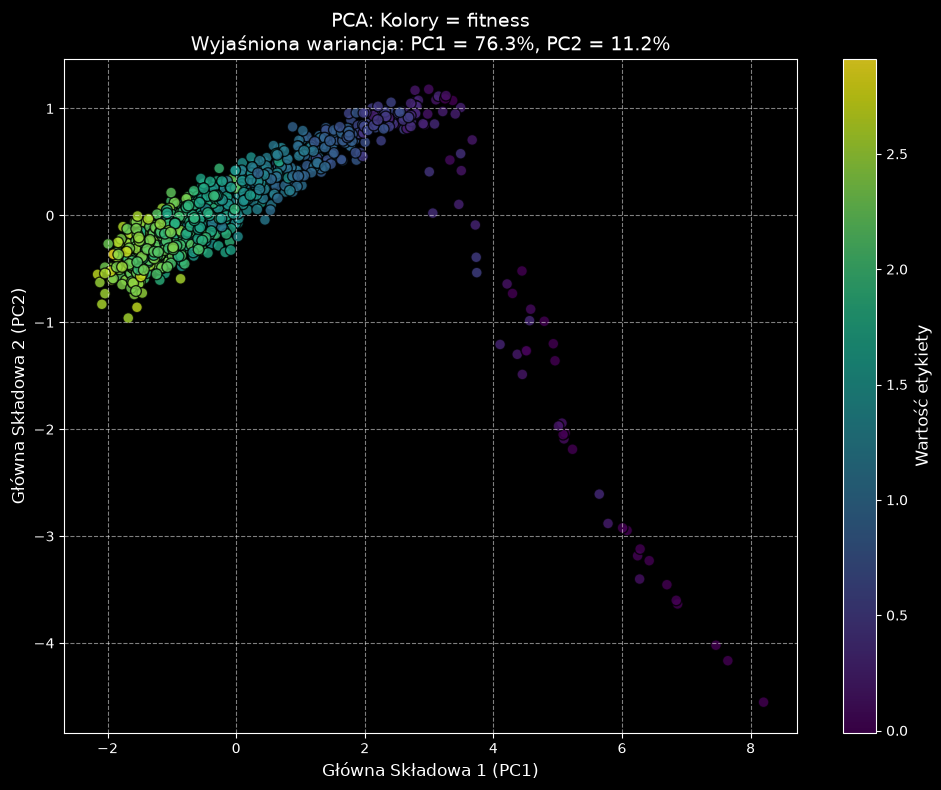

In [8]:
def visualize_pca_2d(latent_vectors, labels, title="Wizualizacja PCA przestrzeni ukrytej (2D)"):
	# 1. Konwersja listy tensorów PyTorch na jedną, płaską macierz Numpy
	if isinstance(latent_vectors[0], torch.Tensor):
		z_matrix = torch.stack(latent_vectors).numpy()
	else:
		z_matrix = np.array(latent_vectors)

	labels = np.array(labels)

	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

	pca = PCA(n_components=2)
	z_pca = pca.fit_transform(z_matrix)

	explained_variance = pca.explained_variance_ratio_ * 100

	plt.figure(figsize=(10, 8))

	# Wykres punktowy
	scatter = plt.scatter(
		z_pca[:, 0],
		z_pca[:, 1],
		c=labels,
		cmap='viridis',
		marker='o',
		edgecolors='black',
		alpha=0.8,
		s=60
	)

	cbar = plt.colorbar(scatter)
	cbar.set_label('Wartość etykiety', fontsize=12)

	# for i, label in enumerate(labels):
	#     formatted_label = f"{label:.2f}" if isinstance(label, float) else str(label)
	#
	#     plt.annotate(
	#         formatted_label,
	#         (z_pca[i, 0], z_pca[i, 1]),
	#         textcoords="offset points",
	#         xytext=(5, 4),
	#         ha='left',
	#         fontsize=8,
	#         alpha=0.95
	#     )

	plt.title(f'{title}\nWyjaśniona wariancja: PC1 = {explained_variance[0]:.1f}%, PC2 = {explained_variance[1]:.1f}%',
			  fontsize=14)
	plt.xlabel(f'Główna Składowa 1 (PC1)', fontsize=12)
	plt.ylabel(f'Główna Składowa 2 (PC2)', fontsize=12)
	plt.grid(True, linestyle='--', alpha=0.5)

	plt.tight_layout()
	plt.show()


print("Generowanie wizualizacji PCA dla fitnessu...")
visualize_pca_2d(latent_vectors, labels, title=f"PCA: Kolory = {config_gae['locality_loss_type']}")


## PCA 3D

In [6]:
if isinstance(latent_vectors[0], torch.Tensor):
	z_matrix = torch.stack(latent_vectors).numpy()
else:
	z_matrix = np.array(latent_vectors)

pca3d = PCA(n_components=3)
z_pca = pca3d.fit_transform(z_matrix)


def visualize_pca_3d_interactive(pca3d, labels, title="Interaktywne PCA 3D"):
	labels = np.array(labels)
	assert len(z_matrix) == len(labels), "Liczba wektorów i etykiet musi być identyczna!"

	exp_var = pca3d.explained_variance_ratio_ * 100

	hover_texts = [f"Wartość: {lbl:.3f}" if isinstance(lbl, float) else f"Wartość: {lbl}" for lbl in labels]

	df = pd.DataFrame({
		'PC1': z_pca[:, 0],
		'PC2': z_pca[:, 1],
		'PC3': z_pca[:, 2],
		'Etykieta': labels,
		'Szczegóły': hover_texts
	})

	fig = px.scatter_3d(
		df,
		x='PC1',
		y='PC2',
		z='PC3',
		color='Etykieta',  # Kolorowanie na podstawie przekazanych etykiet (np. fitness)
		hover_name='Szczegóły',  # Tekst pojawiający się po najechaniu myszką
		title=f'{title} (Zachowana wariancja: {sum(exp_var):.1f}%)',
		labels={
			'PC1': f'PC1 ({exp_var[0]:.1f}%)',
			'PC2': f'PC2 ({exp_var[1]:.1f}%)',
			'PC3': f'PC3 ({exp_var[2]:.1f}%)'
		},
		color_continuous_scale='Viridis',  # Ładna i czytelna mapa kolorów
		opacity=0.85
	)

	fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

	fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

	fig.show()


visualize_pca_3d_interactive(pca3d, labels, title="PCA 3D: Kolory = Fitness")

# Generator struktury 3D pojedynczego osobnika

In [7]:
def get_plotly_traces(X, A, node_color='#1f77b4', edge_color='#7f8c8d'):
	x, y, z = X[:, 0], X[:, 1], X[:, 2]

	# Krawędzie
	edge_x, edge_y, edge_z = [], [], []
	n = A.shape[0]
	for i in range(n):
		for j in range(i + 1, n):
			if A[i, j] > 0.5:
				edge_x.extend([x[i], x[j], None])
				edge_y.extend([y[i], y[j], None])
				edge_z.extend([z[i], z[j], None])

	trace_edges = go.Scatter3d(
		x=edge_x, y=edge_y, z=edge_z,
		mode='lines',
		line=dict(color=edge_color, width=8),
		hoverinfo='none',
		showlegend=False
	)

	# Węzły
	trace_nodes = go.Scatter3d(
		x=x, y=y, z=z,
		mode='markers',
		marker=dict(
			size=8,
			color=node_color,
			line=dict(color='white', width=2),
			symbol='circle'
		),
		hoverinfo='none',
		showlegend=False
	)

	# Stałe podłoże o wymiarach 3 X 3 (od -1.5 do 1.5)
	half_size = 1.5
	z_min = z.min()
	ground_z = z_min - 0.05

	gx = [-half_size, half_size, half_size, -half_size, -half_size]
	gy = [-half_size, -half_size, half_size, half_size, -half_size]
	gz = [ground_z, ground_z, ground_z, ground_z, ground_z]

	trace_ground = go.Scatter3d(
		x=gx, y=gy, z=gz,
		mode='lines',
		line=dict(color='#bdc3c7', width=3),
		hoverinfo='none',
		showlegend=False
	)

	return trace_edges, trace_nodes, trace_ground

# Wizualizacja grid search przykładowego osobnika

In [10]:
def visualize_pca_grid_search_plotly(autoencoder, pca, base_z, step_size=1.0, num_steps_side=3):
	alphas = np.linspace(-step_size * num_steps_side, step_size * num_steps_side, 2 * num_steps_side + 1)
	cols = len(alphas)
	rows = 3

	subplot_titles = [f"PC{r + 1} | Krok: {alpha:.1f}" for r in range(rows) for alpha in alphas]

	fig = make_subplots(
		rows=rows, cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.01,
		vertical_spacing=0.03
	)

	if isinstance(base_z, torch.Tensor):
		base_z = base_z.numpy()

	directions = pca.components_[:3]
	autoencoder.eval()

	for pc_idx in range(rows):
		direction = directions[pc_idx]
		for step_idx, alpha in enumerate(alphas):
			z_new = base_z + alpha * direction
			z_tensor = torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)

			with torch.no_grad():
				X_prime, A_prime = autoencoder.decode(z_tensor)

			X = X_prime.squeeze(0).numpy()
			A = A_prime.squeeze(0).numpy()

			trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

			row = pc_idx + 1
			col = step_idx + 1

			fig.add_trace(trace_edges, row=row, col=col)
			fig.add_trace(trace_nodes, row=row, col=col)
			fig.add_trace(trace_ground, row=row, col=col)

	fig.update_scenes(
		xaxis_visible=False,
		yaxis_visible=False,
		zaxis_visible=False,
		xaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		yaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		zaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		camera=dict(eye=dict(x=1.3, y=1.3, z=0.1))
	)

	fig.update_layout(
		height=900,
		width=2000,
		paper_bgcolor='white',
		plot_bgcolor='white',
		margin=dict(l=0, r=0, b=0, t=30),
		title=dict(text="Grid Search w Przestrzeni PCA", x=0.5, font=dict(size=20))
	)
	fig.update_annotations(font=dict(color='black', size=11))
	fig.show()
	fig.write_image("pca_grid_search.pdf")


visualize_pca_grid_search_plotly(autoencoder, pca3d, latent_vectors[0], 0.1, 2)

# Wizualizacja przejścia od najsłabszego do najlepszego rozwiązania (wraz z ekstrapolacją)

## Pomocnicze metody

In [14]:
def visualize_evolutionary_path_grid(autoencoder, path_vectors, subplot_titles=None):
	num_steps = len(path_vectors)

	fig = make_subplots(
		rows=1, cols=num_steps,
		specs=[[{'type': 'scatter3d'} for _ in range(num_steps)]],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.01
	)

	autoencoder.eval()

	for idx, z_vec in enumerate(path_vectors):
		if isinstance(z_vec, np.ndarray):
			z_tensor = torch.tensor(z_vec, dtype=torch.float32).unsqueeze(0)
		else:
			z_tensor = z_vec.clone().detach().type(torch.float32).unsqueeze(0)

		with torch.no_grad():
			X_prime, A_prime = autoencoder.decode(z_tensor)

		X = X_prime.squeeze(0).cpu().numpy()
		A = A_prime.squeeze(0).cpu().numpy()

		trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

		col = idx + 1
		fig.add_trace(trace_ground, row=1, col=col)
		fig.add_trace(trace_edges, row=1, col=col)
		fig.add_trace(trace_nodes, row=1, col=col)

	fig.update_scenes(
		xaxis_visible=False,
		yaxis_visible=False,
		zaxis_visible=False,
		xaxis=dict(showbackground=False),
		yaxis=dict(showbackground=False),
		zaxis=dict(showbackground=False),
		camera=dict(eye=dict(x=1.3, y=1.3, z=1.2))
	)

	fig.update_annotations(font=dict(color='black', size=11))

	fig.update_layout(
		height=400,
		width=250 * num_steps,
		paper_bgcolor='white',
		plot_bgcolor='white',
		margin=dict(l=0, r=0, b=0, t=30),
		title=dict(text="Ewolucyjna ścieżka przejścia: Od min do max fitness", x=0.5, font=dict(size=18, color='black'))
	)

	fig.write_image('szlak_ewolucyjny.png', scale=3)
	fig.show(renderer="png")

In [6]:
def visualize_evolutionary_path_in_pca(pca3d, latent_vectors, labels, path_vectors, subplot_titles=None):
	if isinstance(latent_vectors[0], torch.Tensor):
		z_matrix = torch.stack(latent_vectors).detach().cpu().numpy()
	else:
		z_matrix = np.array(latent_vectors)

	z_pca_pop = pca3d.transform(z_matrix)
	labels_arr = np.array(labels)
	exp_var = pca3d.explained_variance_ratio_ * 100

	hover_texts = [f"Fitness: {lbl:.3f}" if isinstance(lbl, float) else f"Fitness: {lbl}" for lbl in labels_arr]
	df_pop = pd.DataFrame({
		'PC1': z_pca_pop[:, 0],
		'PC2': z_pca_pop[:, 1],
		'PC3': z_pca_pop[:, 2],
		'Fitness': labels_arr,
		'Szczegóły': hover_texts
	})

	if isinstance(path_vectors, torch.Tensor):
		path_array = path_vectors.detach().cpu().numpy()
	elif isinstance(path_vectors, np.ndarray):
		path_array = path_vectors
	else:
		path_array = np.array(
			[v.detach().cpu().numpy() if isinstance(v, torch.Tensor) else np.array(v) for v in path_vectors])

	z_pca_path = pca3d.transform(path_array)
	num_points = path_array.shape[0]

	if subplot_titles is None or len(subplot_titles) != num_points:
		path_hover = [f"Krok {i + 1}" for i in range(num_points)]
	else:
		path_hover = subplot_titles

	fig = go.Figure()

	fig.add_trace(go.Scatter3d(
		x=df_pop['PC1'], y=df_pop['PC2'], z=df_pop['PC3'],
		mode='markers',
		marker=dict(
			size=4,
			color=df_pop['Fitness'],
			colorscale='Viridis',
			opacity=0.4,
			colorbar=dict(title="Fitness", x=1.1)
		),
		text=df_pop['Szczegóły'],
		hoverinfo='text',
		name='Populacja'
	))

	fig.add_trace(go.Scatter3d(
		x=z_pca_path[:, 0], y=z_pca_path[:, 1], z=z_pca_path[:, 2],
		mode='lines+markers',
		line=dict(color='#e74c3c', width=6),
		marker=dict(size=8, color='black', symbol='diamond'),
		text=path_hover,
		hoverinfo='text',
		name='Szlak Ewolucyjny'
	))

	fig.update_layout(
		title=dict(
			text=f'Szlak ewolucyjny w przestrzeni ukrytej PCA (Wariancja: {sum(exp_var):.1f}%)',
			x=0.5,
			font=dict(size=16, color='black')
		),
		scene=dict(
			xaxis_title=f'PC1 ({exp_var[0]:.1f}%)',
			yaxis_title=f'PC2 ({exp_var[1]:.1f}%)',
			zaxis_title=f'PC3 ({exp_var[2]:.1f}%)',
		),
		paper_bgcolor='white',
		plot_bgcolor='white',
		margin=dict(l=0, r=0, b=0, t=50),
		legend=dict(x=0.05, y=0.95)
	)

	fig.show()

Poniższy kod dzieli próbkę osobników i ich wektorów w przestrzeni latentnej na kubełki, wylicza średnią wartość każdego kubełka, tworząc reprezentantów każdego fitness. Zebrane średnie wektory przestrzeni latentnej wykorzystywane są do wizualizacji przejścia przez te wektory. Można dobrać interesujący zakres

In [19]:
labels_arr = np.array(labels)
z_matrix = np.array([z.cpu().numpy() if isinstance(z, torch.Tensor) else z for z in latent_vectors])

fitness_min = 0.0
fitness_max = 39.0

mask = (labels_arr >= fitness_min) & (labels_arr <= fitness_max)
z_matrix = z_matrix[mask]
labels_arr = labels_arr[mask]

if len(labels_arr) == 0:
	raise ValueError("Brak osobników spełniających kryteria wybranego zakresu fitness!")

sorted_indices = np.argsort(labels_arr)
sorted_z = z_matrix[sorted_indices]
sorted_fitness = labels_arr[sorted_indices]

num_bins = min(10, len(sorted_z))
chunks = np.array_split(np.arange(len(sorted_z)), num_bins)

bin_vectors = []
bin_fitnesses = []
subplot_titles = []

for i, chunk in enumerate(chunks):
	if len(chunk) > 0:
		mean_z = np.mean(sorted_z[chunk], axis=0)
		mean_fit = np.mean(sorted_fitness[chunk])
		bin_vectors.append(mean_z)
		bin_fitnesses.append(mean_fit)
		subplot_titles.append(f"Kubełek {i + 1}\nFit: {mean_fit:.2f}")

bin_vectors = np.array(bin_vectors)

path_vectors = list(bin_vectors)
num_extrap_steps = 3

if len(bin_vectors) >= 2:
	window_size = min(5, len(bin_vectors))
	recent_bins = bin_vectors[-window_size:]
	trend_vector = np.mean(np.diff(recent_bins, axis=0), axis=0)

	for step in range(1, num_extrap_steps + 1):
		extrap_z = bin_vectors[-1] + step * trend_vector
		path_vectors.append(extrap_z)
		subplot_titles.append(f"Ekstrap. +{step}\n(Trend)")

path_vectors = np.array(path_vectors)
print(f"Liczba punktów w path_vectors: {len(path_vectors)}")

Liczba punktów w path_vectors: 13


## Wizualizacja osobników na ścieżce

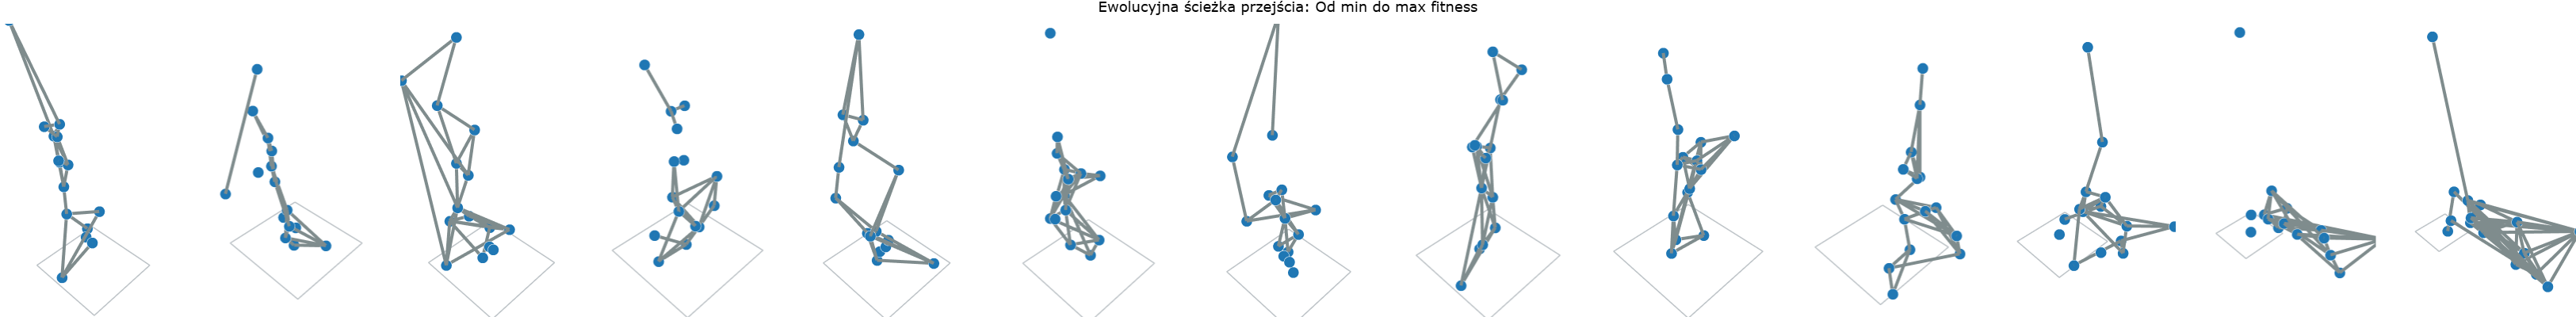

In [17]:
visualize_evolutionary_path_grid(autoencoder, path_vectors)

## Wizualizacja ścieżki w przestrzeni ukrytej

In [20]:
visualize_evolutionary_path_in_pca(pca3d, latent_vectors, labels, path_vectors)

# Wizualizacja otoczenia danych wartości przestrzeni ukrytej

In [11]:
# Zwizualizowane osobniki w postaci macierzy wektora cech ukrytych (pionowego pasa) i odchodzących na boki zmienionych wartości
def visualize_latent_grid_search_plotly(autoencoder, base_z, step_size=0.1, num_steps_side=2):
	if isinstance(base_z, torch.Tensor):
		base_z = base_z.detach().cpu().numpy()

	latent_dim = len(base_z)
	dim_indices = list(range(latent_dim))

	alphas = np.linspace(-step_size * num_steps_side, step_size * num_steps_side, 2 * num_steps_side + 1)
	cols = len(alphas)
	rows = len(dim_indices)

	subplot_titles = [f"Dim {d} | Krok: {alpha:.2f}" for d in dim_indices for alpha in alphas]

	fig = make_subplots(
		rows=rows, cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.01,
		vertical_spacing=0.03
	)

	autoencoder.eval()

	for row_idx, d in enumerate(dim_indices):
		direction = np.zeros_like(base_z)
		direction[d] = 1.0

		for step_idx, alpha in enumerate(alphas):
			z_new = base_z + alpha * direction
			z_tensor = torch.tensor(z_new, dtype=torch.float32).unsqueeze(0)

			with torch.no_grad():
				X_prime, A_prime = autoencoder.decode(z_tensor)

			X = X_prime.squeeze(0).cpu().numpy()
			A = A_prime.squeeze(0).cpu().numpy()

			trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

			row = row_idx + 1
			col = step_idx + 1

			fig.add_trace(trace_edges, row=row, col=col)
			fig.add_trace(trace_nodes, row=row, col=col)
			fig.add_trace(trace_ground, row=row, col=col)

	fig.update_scenes(
		xaxis_visible=False,
		yaxis_visible=False,
		zaxis_visible=False,
		xaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		yaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		zaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		camera=dict(eye=dict(x=1.3, y=1.3, z=0.1))
	)

	fig.update_layout(
		height=300 * rows,
		width=min(2500, 250 * cols),
		paper_bgcolor='white',
		plot_bgcolor='white',
		margin=dict(l=0, r=0, b=0, t=30),
		title=dict(text="Grid Search w Przestrzeni Pojedynczych Wymiarów Latent", x=0.5, font=dict(size=20))
	)
	fig.update_annotations(font=dict(color='black', size=10))
	fig.show(renderer='png')
	fig.write_image("latent_grid_search.pdf")

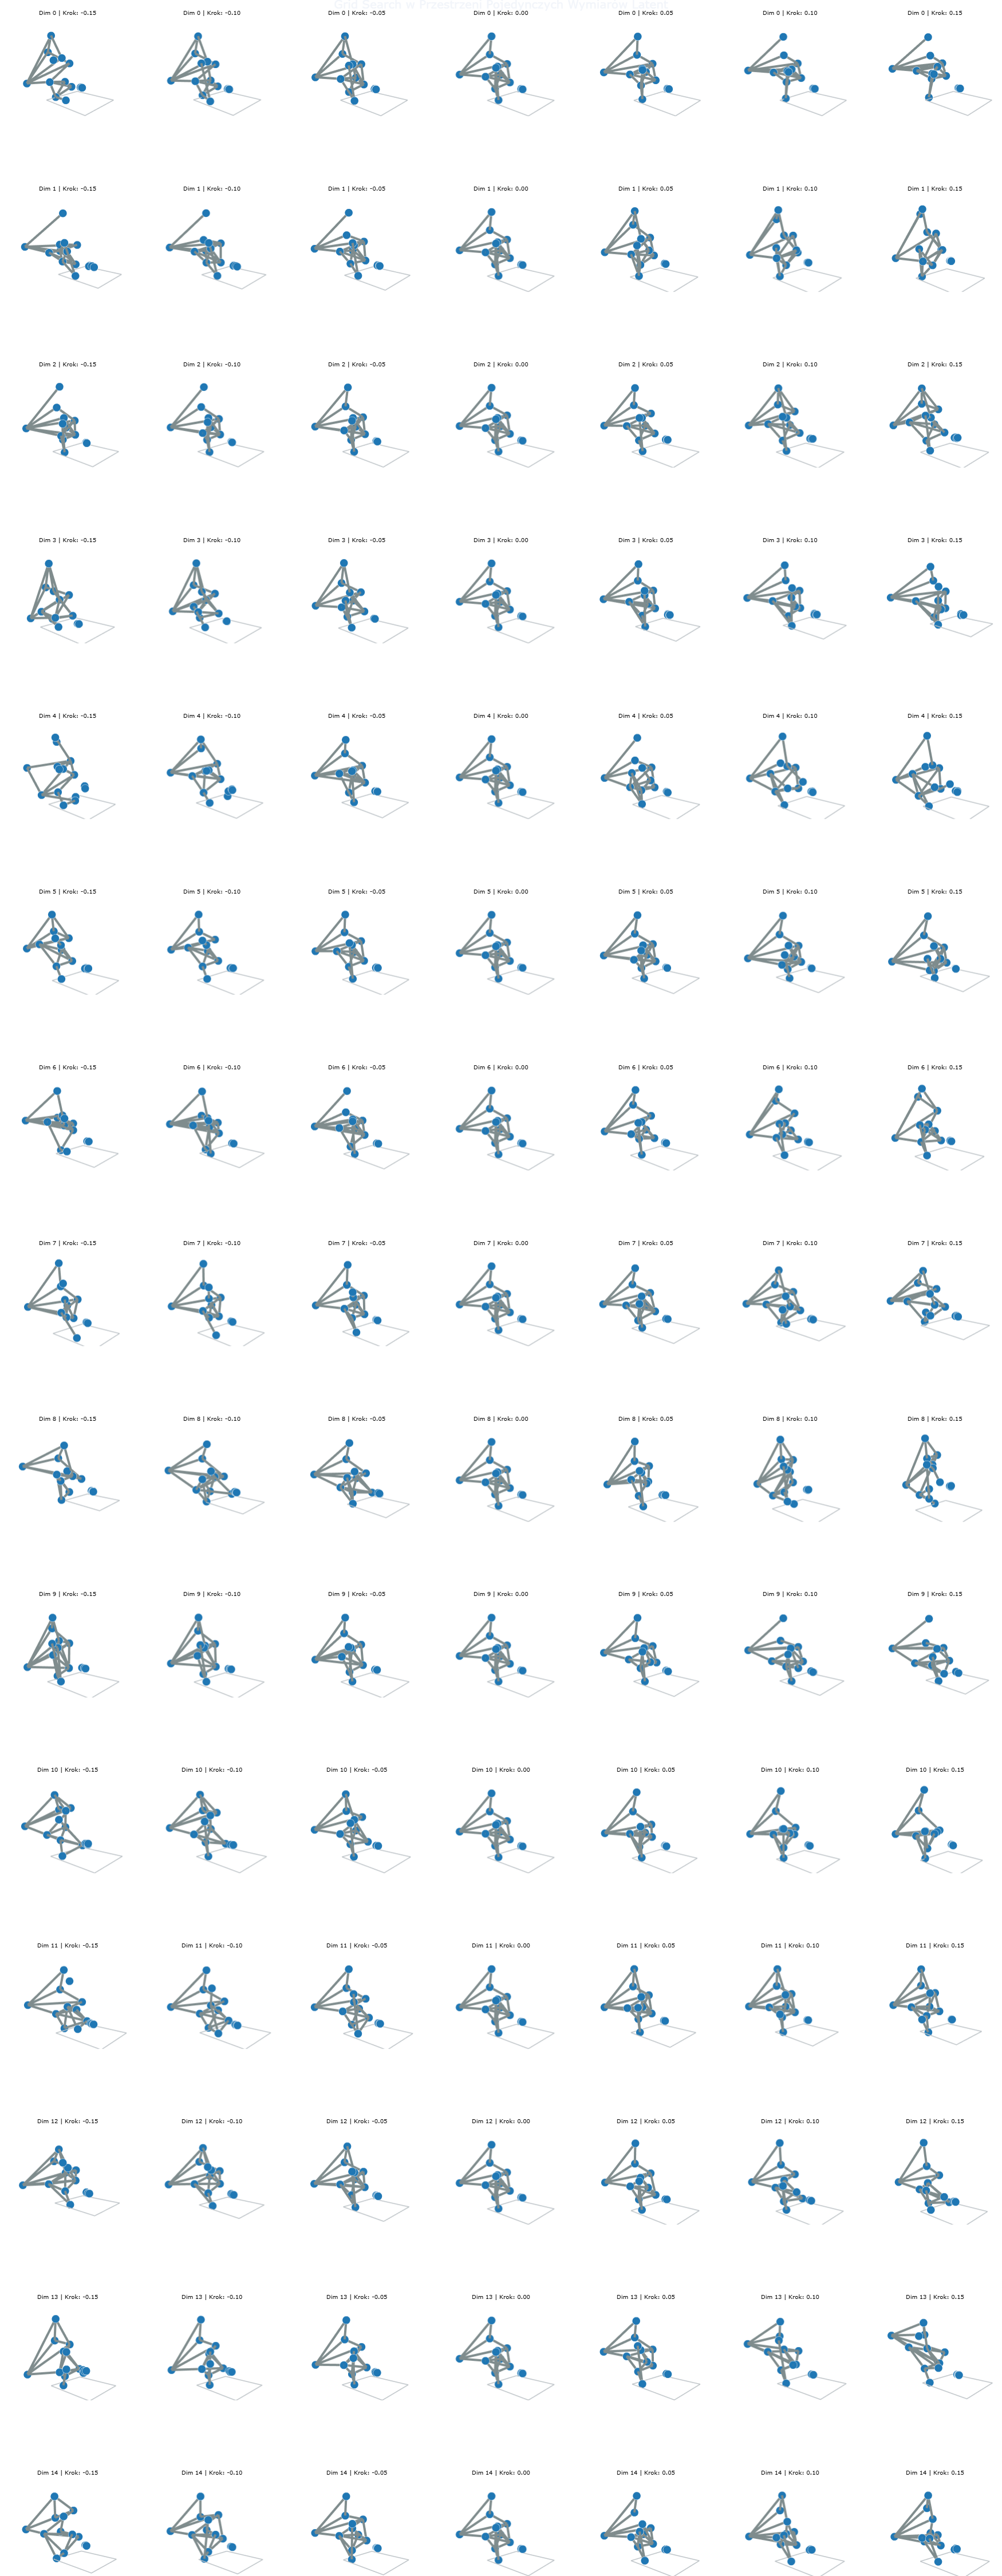

In [30]:
visualize_latent_grid_search_plotly(autoencoder, latent_vectors[0], 0.05, 3)

# Badanie zdegenerowanej przestrzeni

In [21]:
def visualize_degenerate_individuals(
		pca3d, latent_vectors,
		lower_percentile=85, upper_percentile=98,
		title="Osobniki Zdegenerowane (Outliery)"
):
	# 1. Konwersja do tablicy NumPy
	if isinstance(latent_vectors[0], torch.Tensor):
		z = torch.stack(latent_vectors).detach().cpu().numpy()
	else:
		z = np.asarray(latent_vectors)

	# 2. Odległości od centroidu populacji
	centroid = np.mean(z, axis=0)
	distances = np.linalg.norm(z - centroid, axis=1)

	# 3. Maski na podstawie percentyli odległości
	d_min = np.percentile(distances, lower_percentile)
	d_max = np.percentile(distances, upper_percentile)
	deg_mask = (distances >= d_min) & (distances <= d_max)
	norm_mask = ~deg_mask

	# 4. Rzutowanie PCA
	z_pca = pca3d.transform(z)
	exp_var = pca3d.explained_variance_ratio_ * 100

	# 5. Wykres przestrzeni
	fig = plt.figure(figsize=(10, 8))
	ax = fig.add_subplot(111, projection='3d')

	# Populacja bazowa (tło) - kolorujemy odległością od centroidu
	p = ax.scatter(
		z_pca[norm_mask, 0],
		z_pca[norm_mask, 1],
		z_pca[norm_mask, 2],
		c=distances[norm_mask],
		cmap='viridis',
		s=12,
		alpha=0.35,
		label='Populacja standardowa'
	)
	plt.colorbar(p, ax=ax, label='Odległość euklidesowa od centroidu', shrink=0.6)

	# Osobniki zdegenerowane (odstające)
	ax.scatter(
		z_pca[deg_mask, 0],
		z_pca[deg_mask, 1],
		z_pca[deg_mask, 2],
		c='#e74c3c',
		marker='x',
		s=45,
		alpha=0.9,
		label=f'Zdegenerowane ({lower_percentile}-{upper_percentile}%)'
	)

	ax.set_title(f"{title} (Wyjaśniona wariancja: {sum(exp_var):.1f}%)")
	ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}%)")
	ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}%)")
	ax.set_zlabel(f"PC3 ({exp_var[2]:.1f}%)")
	ax.legend(loc='upper left')
	plt.tight_layout()
	plt.show()

	# Zwraca tylko wyselekcjonowane wektory latentne
	return z[deg_mask]

In [22]:
def visualize_degenerate_phenotypes(
		autoencoder,
		degenerate_vectors,
		cols=4,
		max_individuals=16,
		output_pdf="degenerate_phenotypes.pdf"
):
	n_samples = int(min(len(degenerate_vectors), max_individuals))
	if n_samples == 0:
		print("Brak osobników do wyświetlenia.")
		return

	# 1. Przygotowanie wektorów
	if isinstance(degenerate_vectors, torch.Tensor):
		z_sample = degenerate_vectors[:n_samples].float()
	else:
		z_sample = torch.tensor(np.asarray(degenerate_vectors[:n_samples]), dtype=torch.float32)

	# 2. Wymiary siatki
	cols = int(min(cols, n_samples))
	rows = int(math.ceil(n_samples / cols))

	subplot_titles = [f"Osobnik #{i + 1}" for i in range(n_samples)]

	fig = make_subplots(
		rows=rows,
		cols=cols,
		specs=[[{'type': 'scatter3d'} for _ in range(cols)] for _ in range(rows)],
		subplot_titles=subplot_titles,
		horizontal_spacing=0.02,
		vertical_spacing=0.05
	)

	# 3. Zdekodowanie osobników
	autoencoder.eval()
	with torch.no_grad():
		X_all, A_all = autoencoder.decode(z_sample)

	for idx in range(n_samples):
		X = X_all[idx].numpy()
		A = A_all[idx].numpy()

		trace_edges, trace_nodes, trace_ground = get_plotly_traces(X, A)

		r = (idx // cols) + 1
		c = (idx % cols) + 1

		fig.add_trace(trace_edges, row=r, col=c)
		fig.add_trace(trace_nodes, row=r, col=c)
		fig.add_trace(trace_ground, row=r, col=c)

	# 4. Stylizacja scen 3D
	fig.update_scenes(
		xaxis_visible=False,
		yaxis_visible=False,
		zaxis_visible=False,
		xaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		yaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		zaxis=dict(showbackground=False, backgroundcolor="rgba(0,0,0,0)"),
		camera=dict(eye=dict(x=1.3, y=1.3, z=0.1))
	)

	fig.update_layout(
		height=320 * rows,
		width=300 * cols,
		paper_bgcolor='white',
		plot_bgcolor='white',
		showlegend=False,
		margin=dict(l=10, r=10, b=10, t=50),
		title=dict(text=f"Fenotypy Zdegenerowanych Osobników (n={n_samples})", x=0.5, font=dict(size=18))
	)
	fig.update_annotations(font=dict(color='black', size=11))

	fig.show()

	if output_pdf:
		fig.write_image(output_pdf)

>>> PRZED WYWOŁANIEM FUNKCJI


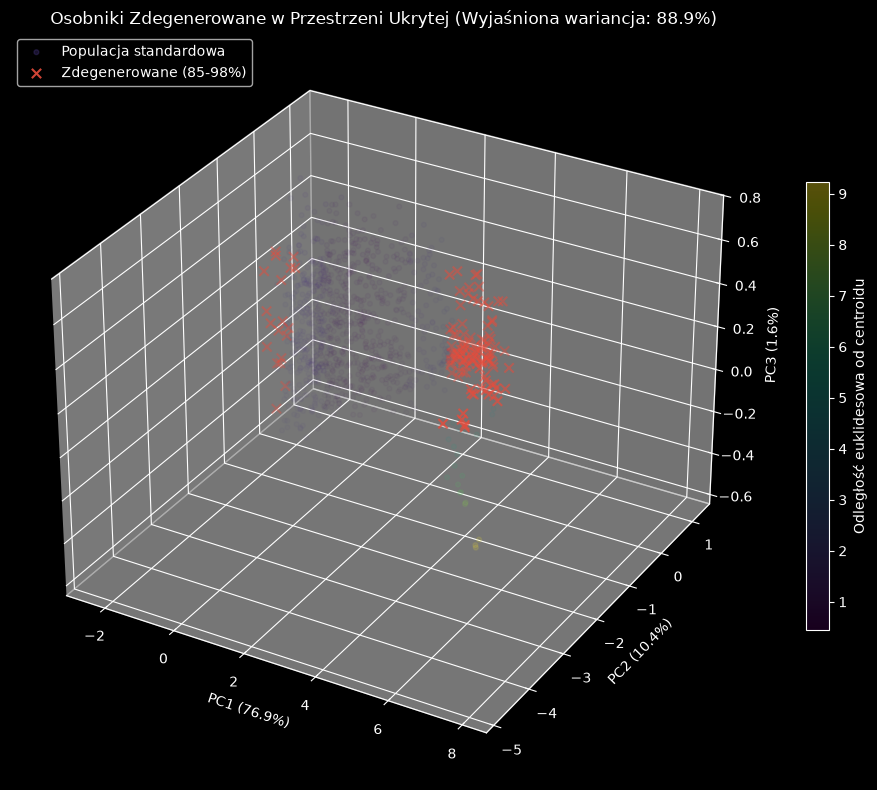

In [24]:
print(">>> PRZED WYWOŁANIEM FUNKCJI", flush=True)
deg_vectors = visualize_degenerate_individuals(
	pca3d=pca3d,
	latent_vectors=latent_vectors,
	lower_percentile=85,
	upper_percentile=98,
	title="Osobniki Zdegenerowane w Przestrzeni Ukrytej"
)

In [26]:
# 2. Wizualizacja fenotypów (domyślnie wyświetla max 16 sztuk w układzie 4x4)
visualize_degenerate_phenotypes(
	autoencoder=autoencoder,
	degenerate_vectors=deg_vectors,
	cols=4,
	max_individuals=12,
	output_pdf="degenerate_phenotypes.pdf"
)

# Wizualizacja 'strefy bezpiecznej'

In [72]:
def generate_fibonacci_sphere(num_samples, radius=1.0):
    """
    Generuje punkty równomiernie rozłożone na obrzeżach sfery 3D (powierzchni)
    za pomocą spiralnej siatki Fibonacciego jako float32.
    """
    points = np.empty((num_samples, 3), dtype=np.float32)
    phi = (1 + np.sqrt(5)) / 2  # złoty podział

    indices = np.arange(num_samples, dtype=np.float32)
    y = 1.0 - (indices / (num_samples - 1)) * 2.0  # od 1 do -1
    r_at_y = np.sqrt(1.0 - y * y)

    theta = 2.0 * np.pi * indices / phi

    points[:, 0] = np.cos(theta) * r_at_y * radius
    points[:, 1] = y * radius
    points[:, 2] = np.sin(theta) * r_at_y * radius

    return points


def explore_safe_zone_sphere(
    pca3d,
    base_vector,
    radius=1.0,
    num_samples=100,
    title="Otoczenie Sferyczne Wybrańca"
):
    # 1. Konwersja wektora bazowego
    if isinstance(base_vector, torch.Tensor):
        base_z = base_vector.detach().cpu().numpy().astype(np.float32)
    else:
        base_z = np.asarray(base_vector, dtype=np.float32)

    # 2. Rzutujemy wektor bazowy na przestrzeń 3D PCA
    base_pca = pca3d.transform(base_z.reshape(1, -1))[0].astype(np.float32)

    # 3. Tworzymy powłokę sfery (obrzeża) w przestrzeni PCA
    sphere_offsets = generate_fibonacci_sphere(num_samples=num_samples, radius=radius)
    sphere_pca = (base_pca + sphere_offsets).astype(np.float32)

    # 4. Rzutowanie punktów z powrotem do przestrzeni latentnej
    sphere_z = pca3d.inverse_transform(sphere_pca).astype(np.float32)

    # 5. Ewaluacja osobnika centralnego
    evaluator = AutoencoderEvaluator(autoencoder, frams_lib, evolution_config['opt_criteria'], evolution_config)
    base_fitness_tuple, _, _, _, _ = evaluator(base_z)
    base_fitness = float(base_fitness_tuple[0])

    # 6. Ewaluacja i walidacja osobników otoczenia
    is_valid = np.zeros(num_samples, dtype=bool)
    fitnesses = np.zeros(num_samples, dtype=np.float32)

    for i in range(num_samples):
        fitness_tuple, _, is_valid_ind, _, _ = evaluator(sphere_z[i])
        is_valid[i] = bool(is_valid_ind)
        fitnesses[i] = float(fitness_tuple[0])

    # 7. Grupowanie indeksów
    better_idx = np.where(is_valid & (fitnesses > base_fitness))[0]
    worse_valid_idx = np.where(is_valid & (fitnesses <= base_fitness))[0]
    invalid_idx = np.where(~is_valid)[0]

    # 8. Budowa wykresu Plotly 3D
    exp_var = pca3d.explained_variance_ratio_ * 100
    fig = go.Figure()

    # Ślad 1: Lepsze osobniki (Valid, Fitness > Bazowy) - ZIELONE
    if len(better_idx) > 0:
        better_labels = [f"{fitnesses[i]:.2f}" for i in better_idx]
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[better_idx, 0],
            y=sphere_pca[better_idx, 1],
            z=sphere_pca[better_idx, 2],
            mode='markers+text',
            marker=dict(size=6, color='#2ecc71', opacity=0.9),
            text=better_labels,
            textposition='top center',
            textfont=dict(size=10, color='green'),
            name=f'Lepsze Valid ({len(better_idx)})',
            hovertemplate="<b>Lepszy (Valid)</b><br>Fitness: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
        ))

    # Ślad 2: Gorsze lub równe (Valid, Fitness <= Bazowy) - POMARAŃCZOWE
    if len(worse_valid_idx) > 0:
        worse_labels = [f"{fitnesses[i]:.2f}" for i in worse_valid_idx]
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[worse_valid_idx, 0],
            y=sphere_pca[worse_valid_idx, 1],
            z=sphere_pca[worse_valid_idx, 2],
            mode='markers+text',
            marker=dict(size=5, color='#e67e22', opacity=0.9),
            text=worse_labels,
            textposition='top center',
            textfont=dict(size=10, color='orange'),
            name=f'Gorsze/Równe Valid ({len(worse_valid_idx)})',
            hovertemplate="<b>Gorszy/Równy (Valid)</b><br>Fitness: %{text}<br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
        ))

    # Ślad 3: Uszkodzone (Invalid) - CZERWONE KRZYŻYKI (bez tekstu)
    if len(invalid_idx) > 0:
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[invalid_idx, 0],
            y=sphere_pca[invalid_idx, 1],
            z=sphere_pca[invalid_idx, 2],
            mode='markers',
            marker=dict(size=6, color='#e74c3c', symbol='x', opacity=0.8),
            name=f'Invalid ({len(invalid_idx)})',
            hovertemplate="<b>Invalid</b><br>PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>PC3: %{z:.2f}<extra></extra>"
        ))

    # Ślad 4: Osobnik bazowy (Centrum)
    fig.add_trace(go.Scatter3d(
        x=[base_pca[0]],
        y=[base_pca[1]],
        z=[base_pca[2]],
        mode='markers+text',
        marker=dict(size=11, color='#3498db', symbol='diamond', line=dict(color='black', width=1.5)),
        text=[f"Bazowy: {base_fitness:.2f}"],
        textposition='bottom center',
        textfont=dict(size=12, color='blue'),
        name='Wybraniec (Centrum)',
        hovertemplate=f"<b>Wybraniec</b><br>Fitness: {base_fitness:.2f}<extra></extra>"
    ))

    fig.update_layout(
        title=dict(
            text=f"{title} (Promień: {radius}, n={num_samples})",
            x=0.5,
            font=dict(size=16)
        ),
        scene=dict(
            xaxis_title=f'PC1 ({exp_var[0]:.1f}%)',
            yaxis_title=f'PC2 ({exp_var[1]:.1f}%)',
            zaxis_title=f'PC3 ({exp_var[2]:.1f}%)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        legend=dict(x=0.02, y=0.98),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    fig.show()

    return sphere_z, is_valid, fitnesses

In [73]:
# Wybieramy np. pierwszego zdegenerowanego osobnika jako punkt startowy
chosen_vector = latent_vectors[10]

# Badamy jego otoczenie w sferze o promieniu np. 0.5
sphere_z, validation_mask,fitnesses = explore_safe_zone_sphere(
	pca3d=pca3d,
	base_vector=chosen_vector,
	radius=1.0,
	num_samples=150,
	title="Analiza Strefy Bezpiecznej"
)

In [70]:
sphere_z, validation_mask,fitnesses = explore_safe_zone_sphere(
	pca3d=pca3d,
	base_vector=chosen_vector,
	radius=0.1,
	num_samples=150,
	title="Analiza Strefy Bezpiecznej"
)

In [71]:
sphere_z, validation_mask,fitnesses = explore_safe_zone_sphere(
	pca3d=pca3d,
	base_vector=chosen_vector,
	radius=0.01,
	num_samples=150,
	title="Analiza Strefy Bezpiecznej"
)

## Wersja z hipersferą

In [74]:
def sample_hypersphere_surface(center, radius, num_samples):
    """
    Równomierne próbkowanie powierzchni hipersfery (D-wymiarowej) o zadanym promieniu.
    """
    dim = center.shape[0]
    # Wektor z wielowymiarowego rozkładu Gaussa
    gaussian_directions = np.random.normal(0, 1, size=(num_samples, dim)).astype(np.float32)
    # Normalizacja wektorów do długości 1 (kierunki losowe na sferze S^{D-1})
    norms = np.linalg.norm(gaussian_directions, axis=1, keepdims=True)
    unit_directions = gaussian_directions / norms
    # Przesunięcie i wyskalowanie do promienia R
    return (center + radius * unit_directions).astype(np.float32)

In [75]:
def explore_safe_zone_hypersphere(
    pca3d,
    base_vector,
    radius=1.0,
    num_samples=150,
    title="Otoczenie Hipersferyczne Wybrańca"
):
    # 1. Konwersja wektora bazowego (15 wymiarów)
    if isinstance(base_vector, torch.Tensor):
        base_z = base_vector.detach().cpu().numpy().astype(np.float32).flatten()
    else:
        base_z = np.asarray(base_vector, dtype=np.float32).flatten()

    latent_dim = base_z.shape[0]

    # 2. Próbkowanie powłoki 15D hipersfery bezpośrednio w przestrzeni ukrytej
    hypersphere_z = sample_hypersphere_surface(
        center=base_z,
        radius=radius,
        num_samples=num_samples
    )

    # 3. Ewaluacja osobnika bazowego
    evaluator = AutoencoderEvaluator(autoencoder, frams_lib, evolution_config['opt_criteria'], evolution_config)
    base_fitness_tuple, _, _, _, _ = evaluator(base_z)
    base_fitness = float(base_fitness_tuple[0])

    # 4. Ewaluacja punktów z powierzchni hipersfery w Framsticks
    is_valid = np.zeros(num_samples, dtype=bool)
    fitnesses = np.zeros(num_samples, dtype=np.float32)

    for i in range(num_samples):
        fitness_tuple, _, is_valid_ind, _, _ = evaluator(hypersphere_z[i])
        is_valid[i] = bool(is_valid_ind)
        fitnesses[i] = float(fitness_tuple[0])

    # 5. Rzutowanie 15D -> 3D tylko na potrzeby wizualizacji
    sphere_pca = pca3d.transform(hypersphere_z).astype(np.float32)
    base_pca = pca3d.transform(base_z.reshape(1, -1))[0].astype(np.float32)
    exp_var = pca3d.explained_variance_ratio_ * 100

    # 6. Podział indeksów
    better_idx = np.where(is_valid & (fitnesses > base_fitness))[0]
    worse_valid_idx = np.where(is_valid & (fitnesses <= base_fitness))[0]
    invalid_idx = np.where(~is_valid)[0]

    # 7. Wizualizacja Plotly 3D
    fig = go.Figure()

    # Ślad 1: Valid Lepsze (Zielone)
    if len(better_idx) > 0:
        better_labels = [f"{fitnesses[i]:.2f}" for i in better_idx]
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[better_idx, 0],
            y=sphere_pca[better_idx, 1],
            z=sphere_pca[better_idx, 2],
            mode='markers+text',
            marker=dict(size=6, color='#2ecc71', opacity=0.9),
            text=better_labels,
            textposition='top center',
            textfont=dict(size=10, color='black'),
            name=f'Lepsze Valid ({len(better_idx)})',
            hovertemplate="<b>Lepszy</b><br>Fitness: %{text}<extra></extra>"
        ))

    # Ślad 2: Valid Gorsze/Równe (Pomarańczowe)
    if len(worse_valid_idx) > 0:
        worse_labels = [f"{fitnesses[i]:.2f}" for i in worse_valid_idx]
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[worse_valid_idx, 0],
            y=sphere_pca[worse_valid_idx, 1],
            z=sphere_pca[worse_valid_idx, 2],
            mode='markers+text',
            marker=dict(size=5, color='#e67e22', opacity=0.9),
            text=worse_labels,
            textposition='top center',
            textfont=dict(size=10, color='black'),
            name=f'Gorsze/Równe Valid ({len(worse_valid_idx)})',
            hovertemplate="<b>Gorszy/Równy</b><br>Fitness: %{text}<extra></extra>"
        ))

    # Ślad 3: Invalid (Czerwone krzyżyki bez podpisów)
    if len(invalid_idx) > 0:
        fig.add_trace(go.Scatter3d(
            x=sphere_pca[invalid_idx, 0],
            y=sphere_pca[invalid_idx, 1],
            z=sphere_pca[invalid_idx, 2],
            mode='markers',
            marker=dict(size=6, color='#e74c3c', symbol='x', opacity=0.8),
            name=f'Invalid ({len(invalid_idx)})',
            hovertemplate="<b>Invalid</b><extra></extra>"
        ))

    # Ślad 4: Osobnik bazowy (Centrum)
    fig.add_trace(go.Scatter3d(
        x=[base_pca[0]],
        y=[base_pca[1]],
        z=[base_pca[2]],
        mode='markers+text',
        marker=dict(size=11, color='#3498db', symbol='diamond', line=dict(color='black', width=1.5)),
        text=[f"Bazowy: {base_fitness:.2f}"],
        textposition='bottom center',
        textfont=dict(size=12, color='black'),
        name='Wybraniec (Centrum)',
        hovertemplate=f"<b>Wybraniec</b><br>Fitness: {base_fitness:.2f}<extra></extra>"
    ))

    fig.update_layout(
        title=dict(
            text=f"{title} (Wymiar: {latent_dim}D, Promień: {radius}, n={num_samples})",
            x=0.5,
            font=dict(size=16)
        ),
        scene=dict(
            xaxis_title=f'PC1 ({exp_var[0]:.1f}%)',
            yaxis_title=f'PC2 ({exp_var[1]:.1f}%)',
            zaxis_title=f'PC3 ({exp_var[2]:.1f}%)',
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.2))
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        legend=dict(x=0.02, y=0.98),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    fig.show()

    return hypersphere_z, is_valid, fitnesses

In [77]:
_,_,_ = explore_safe_zone_hypersphere(pca3d,chosen_vector,0.1,150,"Jadło")

# Wizualizacja ścieżki pętli encode -> decode

In [86]:
def visualize_latent_journeys_interactive(
    background_latents,
    trajectories_list,
    fitnesses_list=None,
    show_fitness=True
):
    """
    Wizualizuje wędrówkę (drift) wielu osobników naraz na jednym wykresie.

    :param background_latents: Tło całej populacji w przestrzeni ukrytej
    :param trajectories_list: Lista trajektorii (każda trajektoria to lista/tensor wektorów)
    :param fitnesses_list: Lista list wartości fitness odpowiadająca poszczególnym trajektoriom
    :param show_fitness: Flaga włączająca/wyłączająca wyświetlanie dopisków fitness w labelach
    """
    # 1. Konwersja tła do czystego NumPy
    if isinstance(background_latents, list):
        bg_matrix = np.vstack([v.detach().cpu().numpy() if torch.is_tensor(v) else v for v in background_latents])
    else:
        bg_matrix = background_latents.detach().cpu().numpy() if torch.is_tensor(background_latents) else np.asarray(background_latents)

    # 2. PCA dopasowane na wektorach tła (bazowych)
    pca = PCA(n_components=3)
    pca.fit(bg_matrix)
    bg_pca = pca.transform(bg_matrix)
    exp_var = pca.explained_variance_ratio_ * 100

    # Podpróbkowanie tła (ochrona przed crashem przeglądarki)
    max_bg = 5000
    if bg_pca.shape[0] > max_bg:
        idx = np.random.choice(bg_pca.shape[0], max_bg, replace=False)
        bg_pca_sub = bg_pca[idx]
    else:
        bg_pca_sub = bg_pca

    fig = go.Figure()

    # 3. Rysowanie tła (szare, półprzezroczyste punkty)
    fig.add_trace(go.Scatter3d(
        x=bg_pca_sub[:, 0], y=bg_pca_sub[:, 1], z=bg_pca_sub[:, 2],
        mode='markers',
        marker=dict(size=3, color='lightgray', opacity=0.15),
        name='Przestrzeń Ukryta (Tło)',
        hoverinfo='none'
    ))

    # Wyrazista paleta kolorów (10 kolorów)
    palette = [
        '#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f',
        '#e67e22', '#1abc9c', '#34495e', '#e84393', '#00cec9'
    ]

    # Zabezpieczenie przed brakiem fitnessu
    if fitnesses_list is None:
        fitnesses_list = [None] * len(trajectories_list)

    # 4. Rysowanie kolejnych wędrówek
    for t_idx, (trajectory, fitnesses) in enumerate(zip(trajectories_list, fitnesses_list)):

        # Konwersja trajektorii
        if isinstance(trajectory, list):
            traj_matrix = np.vstack([v.detach().cpu().numpy() if torch.is_tensor(v) else v for v in trajectory])
        else:
            traj_matrix = trajectory.detach().cpu().numpy() if torch.is_tensor(trajectory) else np.asarray(trajectory)

        traj_pca = pca.transform(traj_matrix)
        steps = np.arange(traj_pca.shape[0])

        # Wybór koloru z palety (zapętlenie w razie większej liczby ścieżek)
        path_color = palette[t_idx % len(palette)]

        # Budowanie etykiet: uwzględnienie flagi show_fitness
        if show_fitness and fitnesses is not None:
            point_labels = [
                f"{i} | invalid" if fit < 0 else f"{i} | {fit:.2f}"
                for i, fit in zip(steps, fitnesses)
            ]
        else:
            point_labels = [str(i) for i in steps]

        # Ścieżka
        fig.add_trace(go.Scatter3d(
            x=traj_pca[:, 0],
            y=traj_pca[:, 1],
            z=traj_pca[:, 2],
            mode='lines+markers+text',
            marker=dict(size=5, color=path_color),
            line=dict(color=path_color, width=3),
            text=point_labels,
            textposition='top center',
            # Kolor tekstu taki sam jak kolor ścieżki
            textfont=dict(color=path_color, size=11, family="Arial Black"),
            hovertemplate=f"<b>Ścieżka {t_idx+1}</b><br>%{{text}}<br>PC1: %{{x:.2f}}<br>PC2: %{{y:.2f}}<br>PC3: %{{z:.2f}}<extra></extra>",
            name=f'Ścieżka {t_idx+1}'
        ))

        # Oznaczenie STARTU (Romb)
        fig.add_trace(go.Scatter3d(
            x=[traj_pca[0, 0]], y=[traj_pca[0, 1]], z=[traj_pca[0, 2]],
            mode='markers',
            marker=dict(size=8, color=path_color, symbol='diamond', line=dict(color='black', width=1)),
            showlegend=False, # Ukrywamy powielające się ikony startu w legendzie
            hoverinfo='skip'
        ))

        # Oznaczenie KOŃCA (Mniejszy kwadrat)
        fig.add_trace(go.Scatter3d(
            x=[traj_pca[-1, 0]], y=[traj_pca[-1, 1]], z=[traj_pca[-1, 2]],
            mode='markers',
            marker=dict(size=8, color=path_color, symbol='square', line=dict(color='black', width=1)),
            showlegend=False,
            hoverinfo='skip'
        ))

    # 5. Kosmetyka układu
    fig.update_layout(
        title=dict(text="Wędrówki Osobników (Encode -> Decode Drift)", x=0.5, font=dict(size=18)),
        scene=dict(
            xaxis_title=f'PC1 ({exp_var[0]:.1f}%)',
            yaxis_title=f'PC2 ({exp_var[1]:.1f}%)',
            zaxis_title=f'PC3 ({exp_var[2]:.1f}%)',
            camera=dict(eye=dict(x=1.3, y=1.3, z=1.0))
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        legend=dict(x=0.85, y=0.9),
        paper_bgcolor='white',
        plot_bgcolor='white'
    )

    fig.show()




In [89]:
# Inicjalizacja ewaluatora
evaluator = AutoencoderEvaluator(autoencoder, frams_lib, evolution_config['opt_criteria'], evolution_config)

# Wybieramy np. 3 pierwsze wektory z naszej bazy latent_vectors jako punkty startowe
starting_vectors = latent_vectors[9:11]

trajectories_list = []
fitnesses_list = []
steps = 100

autoencoder.eval()
with torch.no_grad():
    for start_z in starting_vectors:
        trajectory_latent_vector = []
        fitness_history = []

        # Upewniamy się, że start_z jest tensorem [1, latent_dim]
        if not isinstance(start_z, torch.Tensor):
            current_z = torch.tensor(start_z, dtype=torch.float32)
        else:
            current_z = start_z.clone().detach().float()

        if current_z.dim() == 1:
            current_z = current_z.unsqueeze(0)

        for step in range(steps):
            # 1. Konwersja wektora do NumPy dla ewaluatora i zapisu
            z_np = current_z.squeeze(0).cpu().numpy().astype(np.float32)

            # 2. Ewaluacja aktualnego punktu
            fitness_tuple, _, is_valid_ind, _, _ = evaluator(z_np)

            # Zgodnie z poprzednim ustaleniem: jeśli invalid, rzutujemy fitness na wartość ujemną (-1.0)
            fit_val = float(fitness_tuple[0]) if is_valid_ind else -1.0

            # 3. Zapisanie kroku do historii ścieżki
            trajectory_latent_vector.append(z_np)
            fitness_history.append(fit_val)

            # 4. Przejście przez Autoenkoder (Dekodowanie i ponowne Zakodowanie), aby uzyskać krok n+1
            x_prime, a_probs = autoencoder.decode(current_z)
            current_z = autoencoder.encode(x_prime, a_probs)

        # Po zakończeniu pętli dla jednego osobnika, dodajemy jego trasę do głównych list
        trajectories_list.append(trajectory_latent_vector)
        fitnesses_list.append(fitness_history)

# Wywołanie nowej wizualizacji z przygotowanymi listami ścieżek
visualize_latent_journeys_interactive(
    background_latents=latent_vectors,
    trajectories_list=trajectories_list,
    fitnesses_list=fitnesses_list,
    show_fitness=True
)